### Space Missions from 1957 to 2022

Project done in celebration of the launches from new contenders in the space race as well as the eventual return of the US to the moon through the Artimus program 

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(81)


data_path = "C:/Users/raadams/Documents/Notebooks/nasa_dataset/Space_Missions/space_missions.csv"

# read in using pandas and perform and inspection
df = pd.read_csv(data_path, encoding='latin1') # got error about utf-8 so added extra condition
print(df.head(5)) # check data

     Company                                   Location       Date      Time  \
0  RVSN USSR  Site 1/5, Baikonur Cosmodrome, Kazakhstan  10/4/1957  19:28:00   
1  RVSN USSR  Site 1/5, Baikonur Cosmodrome, Kazakhstan  11/3/1957   2:30:00   
2    US Navy   LC-18A, Cape Canaveral AFS, Florida, USA  12/6/1957  16:44:00   
3       AMBA   LC-26A, Cape Canaveral AFS, Florida, USA   2/1/1958   3:48:00   
4    US Navy   LC-18A, Cape Canaveral AFS, Florida, USA   2/5/1958   7:33:00   

           Rocket         Mission RocketStatus Price MissionStatus  
0  Sputnik 8K71PS       Sputnik-1      Retired   NaN       Success  
1  Sputnik 8K71PS       Sputnik-2      Retired   NaN       Success  
2        Vanguard    Vanguard TV3      Retired   NaN       Failure  
3          Juno I      Explorer 1      Retired   NaN       Success  
4        Vanguard  Vanguard TV3BU      Retired   NaN       Failure  


In [30]:
# check missing values in each column
print(df.isnull().sum())

# Convert date to specified convention 
# convert date to date and time 
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year

# There is a lot of data missing in the price column compared to time 
# I wont be able to get much out of the data substantially there. 
# It is also not clear what the units are so I may remove for now
df = df.drop(columns=['Price'])

# let's filter between mission success vs. failure 
success_matrix_df = df[df['MissionStatus']=='Success']

# let's also filter by which company or organization launched
nasa_launches_df = df[df['Company'] != 'SpaceX']


Company             0
Location            0
Date                0
Time              127
Rocket              0
Mission             0
RocketStatus        0
Price            3365
MissionStatus       0
dtype: int64


In [31]:
# Group by company and get summary statistics for launch success vs. failures 
print('------------print by statistics-----------------\n')
print(df.groupby('Company')['MissionStatus'].agg(['count','max','min']))

------------print by statistics-----------------

                 count                max              min
Company                                                   
AEB                  3  Prelaunch Failure          Failure
AMBA                 8            Success          Failure
ASI                  9            Success          Success
Arianespace        293            Success          Failure
Armée de l'Air       4            Success  Partial Failure
...                ...                ...              ...
VKS RF             216            Success          Failure
Virgin Galactic      3            Success  Partial Failure
Virgin Orbit         5            Success          Failure
Yuzhmash             2            Success          Success
i-Space              4            Success          Failure

[62 rows x 3 columns]


<Figure size 1200x600 with 0 Axes>

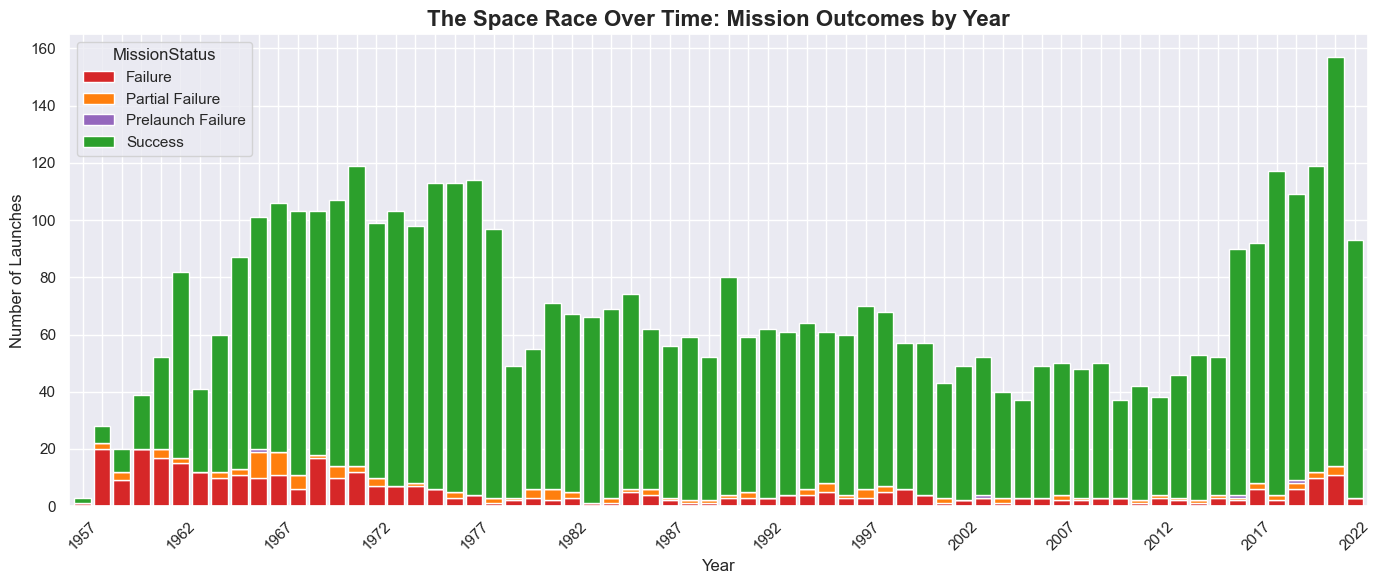

C:\Users\raadams\AppData\Local\Temp\ipykernel_9612\2863557737.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')


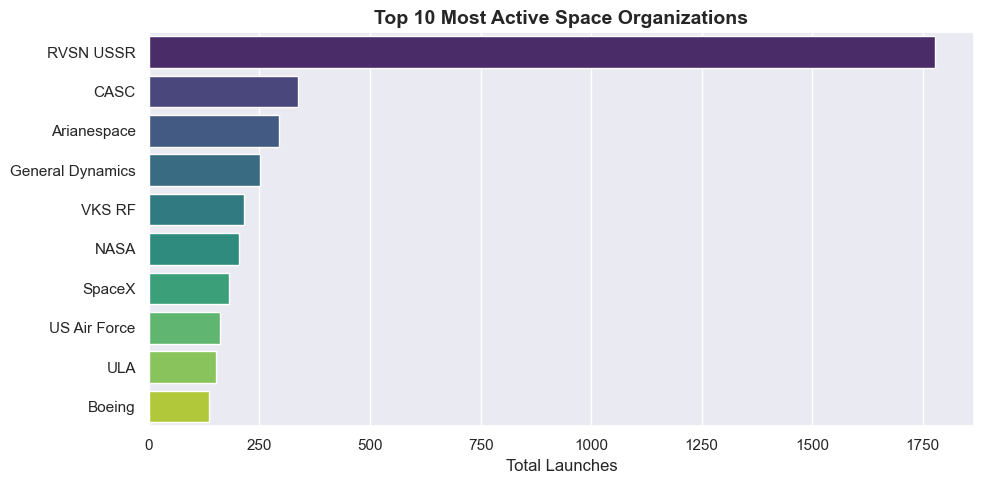

In [32]:
# Extract country from location
df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip() if pd.notnull(x) else '')

sns.set_theme(style="darkgrid")
plt.figure(figsize=(12, 6))

# Missions per year by MissionStatus
mission_counts = df.groupby(['Year', 'MissionStatus']).size().unstack(fill_value=0)
colors = {'Success': '#2ca02c', 'Failure': '#d62728', 'Partial Failure': '#ff7f0e', 'Prelaunch Failure': '#9467bd'}
available_colors = [colors.get(c, '#333333') for c in mission_counts.columns]
mission_counts.plot(kind='bar', stacked=True, figsize=(14, 6), color=available_colors, width=0.85)

plt.title('The Space Race Over Time: Mission Outcomes by Year', fontsize=16, weight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.xticks(rotation=45)
# Show only every 5th year for readability
ax = plt.gca()
for i, label in enumerate(ax.get_xticklabels()):
    if i % 5 != 0:
        label.set_visible(False)
plt.tight_layout()
plt.show()

# Plot 2: Top 10 Companies
plt.figure(figsize=(10, 5))
top_companies = df['Company'].value_counts().nlargest(10)
sns.barplot(x=top_companies.values, y=top_companies.index, palette='viridis')
plt.title('Top 10 Most Active Space Organizations', fontsize=14, weight='bold')
plt.xlabel('Total Launches')
plt.ylabel('')
plt.tight_layout()
plt.show()

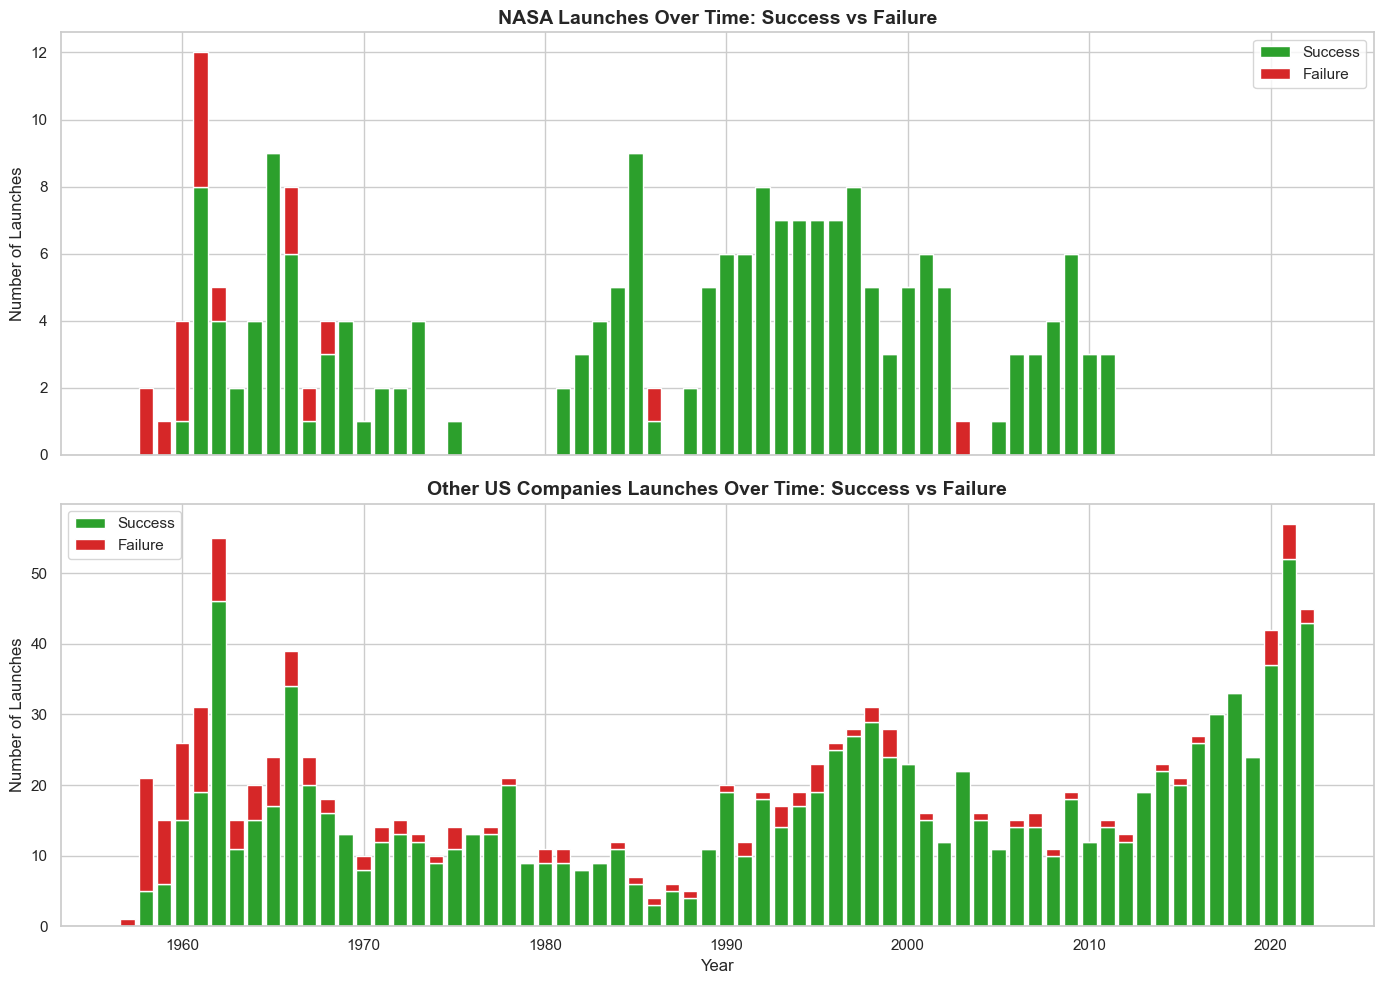

In [33]:
# Extract Country and filter for USA
df['Country'] = df['Location'].apply(lambda x: x.split(',')[-1].strip() if pd.notnull(x) else '')
us_df = df[df['Country'] == 'USA'].copy()

# Categorize Company: NASA vs Other US
us_df['Company_Type'] = us_df['Company'].apply(lambda x: 'NASA' if 'NASA' in x else 'Other US Companies')

# Group by Year, Company_Type, MissionStatus
agg_df = us_df.groupby(['Year', 'Company_Type', 'MissionStatus']).size().unstack(fill_value=0).reset_index()

# Simplify statuses to Success vs. Non-Success (Failure, Partial Failure, Prelaunch Failure)
if 'Success' in agg_df.columns:
    success_col = 'Success'
else:
    success_col = None

# Let's just plot Success vs Failure (grouping non-success)
us_df['Outcome'] = us_df['MissionStatus'].apply(lambda x: 'Success' if x == 'Success' else 'Failure (inc. Partial/Prelaunch)')

# Calculate yearly success rates and total launches
yearly_stats = us_df.groupby(['Year', 'Company_Type', 'Outcome']).size().unstack(fill_value=0).reset_index()
yearly_stats['Total'] = yearly_stats['Success'] + yearly_stats.get('Failure (inc. Partial/Prelaunch)', 0)

# Plotting
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Plot NASA
nasa_data = yearly_stats[yearly_stats['Company_Type'] == 'NASA']
axes[0].bar(nasa_data['Year'], nasa_data['Success'], label='Success', color='#2ca02c')
if 'Failure (inc. Partial/Prelaunch)' in nasa_data.columns:
    axes[0].bar(nasa_data['Year'], nasa_data['Failure (inc. Partial/Prelaunch)'], bottom=nasa_data['Success'], label='Failure', color='#d62728')
axes[0].set_title('NASA Launches Over Time: Success vs Failure', fontsize=14, weight='bold')
axes[0].set_ylabel('Number of Launches')
axes[0].legend()

# Plot Other US
other_data = yearly_stats[yearly_stats['Company_Type'] == 'Other US Companies']
axes[1].bar(other_data['Year'], other_data['Success'], label='Success', color='#2ca02c')
if 'Failure (inc. Partial/Prelaunch)' in other_data.columns:
    axes[1].bar(other_data['Year'], other_data['Failure (inc. Partial/Prelaunch)'], bottom=other_data['Success'], label='Failure', color='#d62728')
axes[1].set_title('Other US Companies Launches Over Time: Success vs Failure', fontsize=14, weight='bold')
axes[1].set_ylabel('Number of Launches')
axes[1].set_xlabel('Year')
axes[1].legend()

plt.tight_layout()
plt.savefig('nasa_vs_us_companies.png', dpi=300)
plt.show()

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Set binary target: 1 for Success, 0 for any Failure
df['Target'] = df['MissionStatus'].apply(lambda x: 1 if x == 'Success' else 0)
df['Month'] = df['Date'].dt.month
# Select basic features
features = ['Company', 'Location', 'RocketStatus', 'Year', 'Month']
X = df[features].copy()
y = df['Target']

# Encode text columns into numbers
for col in ['Company', 'Location', 'RocketStatus']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the Random Forest 
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

# Check the results
y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))

# View top features
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nFeature Importances:\n", importances)

              precision    recall  f1-score   support

           0       0.38      0.19      0.25        94
           1       0.91      0.96      0.94       832

    accuracy                           0.89       926
   macro avg       0.64      0.58      0.60       926
weighted avg       0.86      0.89      0.87       926


Feature Importances:
 Year            0.378466
Location        0.274135
Month           0.209514
Company         0.122801
RocketStatus    0.015085
dtype: float64
